<a href="https://colab.research.google.com/github/anjaruzica/MIDTERManja/blob/main/midterm_ANJA_economic_modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[[  2   2   4   8  14  22]
 [ 32  44  58  74  92 112]]
          a         b         c         d
1  2.252218 -0.176933 -1.297978  0.296180
2 -0.450240  0.793053  0.598620 -0.022913
3 -0.418804 -0.039557  0.779045 -0.012005
4  0.014021 -0.208020 -1.047819 -1.363348
0.5986201724151128
0.5986201724151128
0.5986201724151128


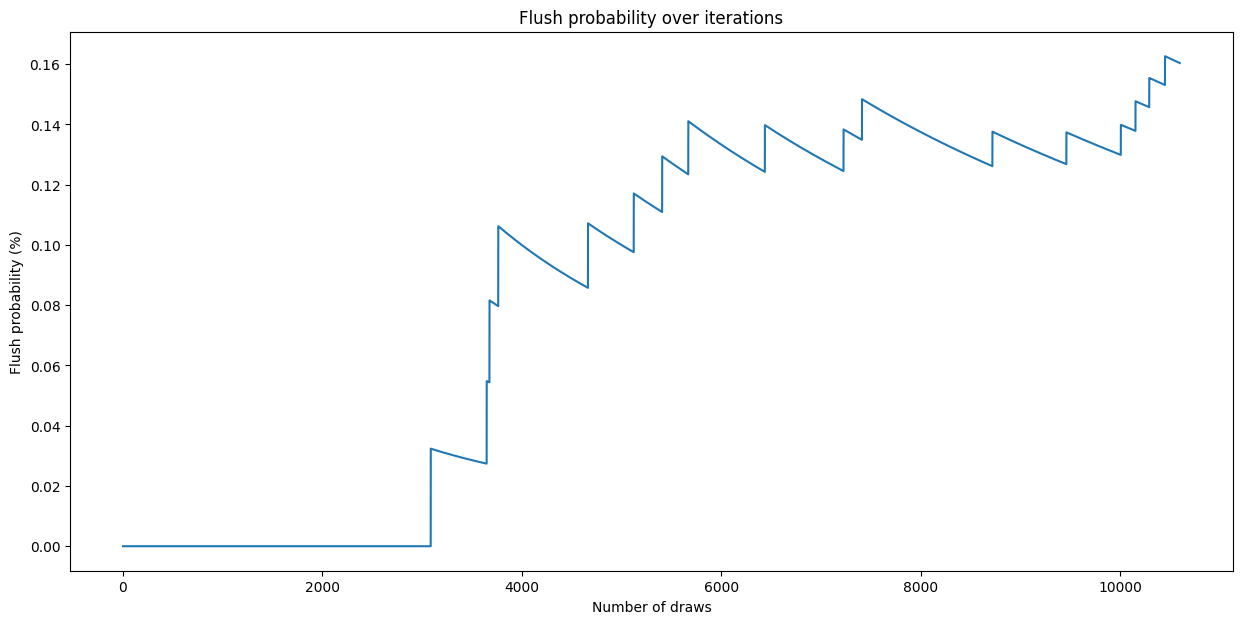

/tmp/ipykernel_6343/2732897978.py:129: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start='2017-01-01', end='2017-12-31', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Final flush probability after 10600 iterations: 0.16037735849056603%


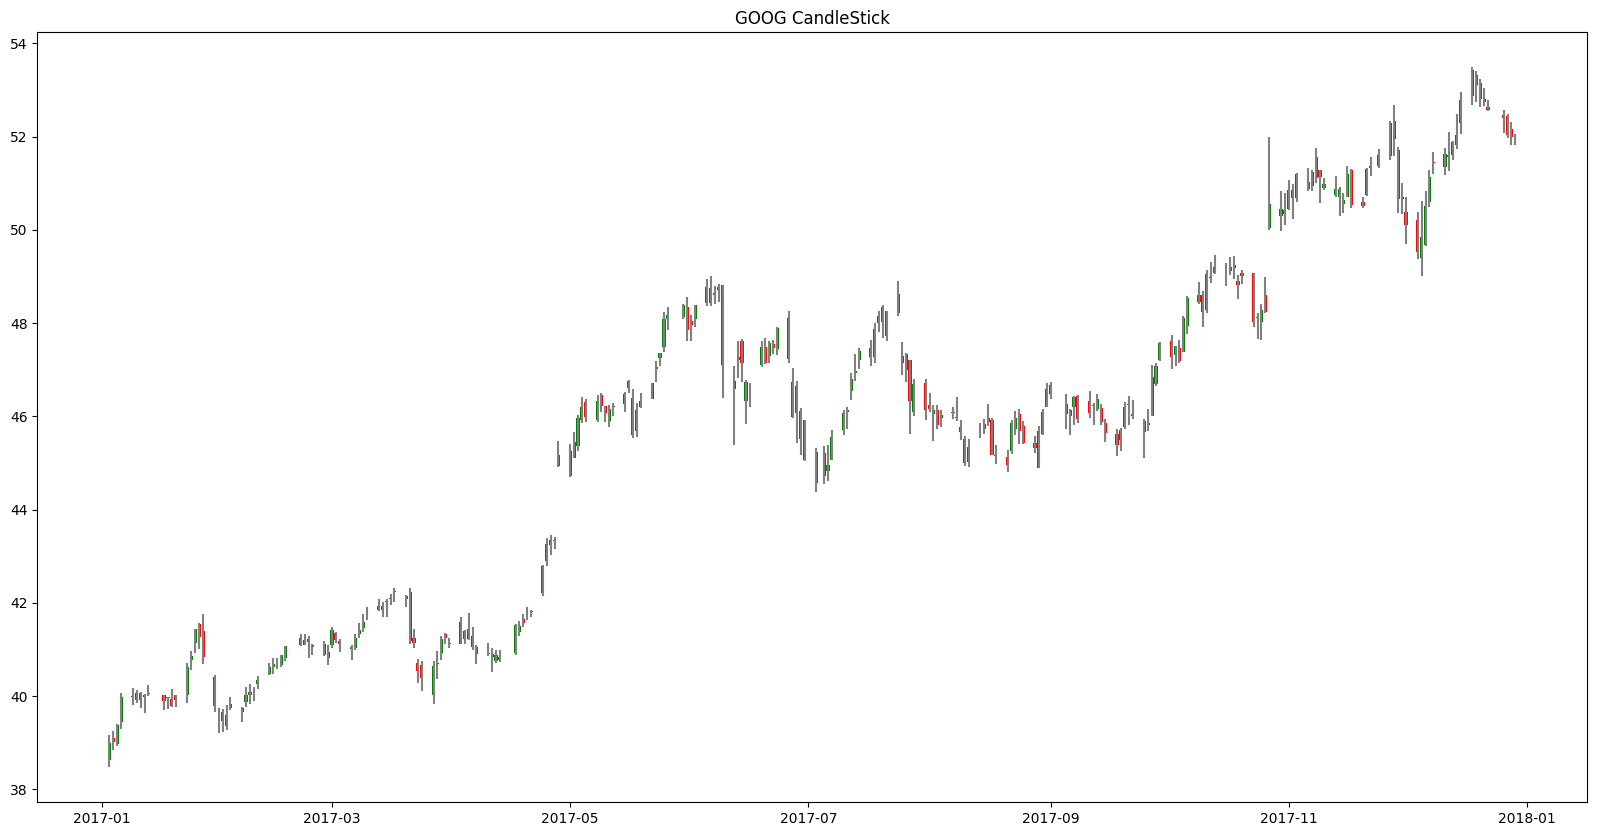

Best day: 2017-09-27 with 1.8054577628392714% gain
Worst day: 2017-06-09 with -3.5215798341573343% loss


In [4]:
#question 1 - midterm exam- Anja Ruzica Cacic Milutinovic

import numpy as np

a = np.arange(0, 12)
a = a**2 - a + 2
a = a.reshape(2, 6)
print(a)
# + answered on BB

#question 2

import numpy as np
import pandas as pd

df = pd.DataFrame(np.random.randn(4, 4), index=[1, 2, 3, 4], columns=['a', 'b', 'c', 'd'])
print(df)

# picking row 2, column c
print(df['c'][2])   # by index
print(df.loc[2, 'c']) # by loc (label based)
print(df.iloc[1, 2])  # by iloc (position based, so row 2 is position 1)
# + answered on BB

#question 3
# answered on BB

#question 4
# answered on BB


# question 5
import random
import matplotlib.pyplot as plt

class PlayingCard:
    SUITS = ["♠", "♥", "♦", "♣"]
    RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

    def __init__(self, suit, rank):
        if suit not in self.SUITS:
            raise ValueError("invalid suit")
        if rank not in self.RANKS:
            raise ValueError("invalid rank")
        self._suit = suit
        self._rank = rank

    @property
    def suit(self):
        return self._suit

    @property
    def rank(self):
        return self._rank

    def __str__(self):
        return f"{self._rank}{self._suit}"

    def __repr__(self):
        return self.__str__()


class Deck:
    def __init__(self):
        self._cards = []
        for suit in PlayingCard.SUITS:
            for rank in PlayingCard.RANKS:
                card = PlayingCard(suit, rank)
                self._cards.append(card)

    def shuffle(self):
        random.shuffle(self._cards)

    def deal(self):
        return self._cards.pop(0)


class PokerHand:
    def __init__(self):
        deck = Deck()
        deck.shuffle()
        _cards = []
        for i in range(5):
            _cards.append(deck.deal())
        self._cards = _cards

    def __str__(self):
        return str(self._cards)

    @property
    def is_flush(self):
        first_suit = self._cards[0].suit
        for i in range(1, 5):
            if first_suit != self._cards[i].suit:
                return False
        return True


iterations = 10600 #@param {type:"slider", min:1000, max:50000, step:100}

hits = 0
x_axis = []
y_axis = []

for i in range(1, iterations + 1):
    hand = PokerHand()
    if hand.is_flush:
        hits += 1
    prob = hits / i * 100
    x_axis.append(i)
    y_axis.append(prob)

plt.figure(figsize=(15, 7))
plt.plot(x_axis, y_axis)
plt.xlabel("Number of draws")
plt.ylabel("Flush probability (%)")
plt.title("Flush probability over iterations")
plt.show()

print(f"Final flush probability after {iterations} iterations: {prob}%")


#question 6
from matplotlib import pylab as plt
import pandas as pd
import yfinance as yf

company = "GOOG"
df = yf.download(company, start='2017-01-01', end='2017-12-31', multi_level_index=False)

plt.figure(f"{company} CandleStick", figsize=(20, 10))
plt.title(f"{company} CandleStick")
plt.vlines(x=df.index, ymin=df.Low, ymax=df.High, color="gray")

green = df.loc[df.Open <= df.Close, ['Open', 'Close', 'High', 'Low']]
green['Height'] = green.Close - green.Open

red = df.loc[df.Open > df.Close, ['Open', 'Close', 'High', 'Low']]
red['Height'] = red.Open - red.Close

plt.bar(x=green.index, height=green.Height, bottom=green.Open, color="green")
plt.bar(x=red.index, height=red.Height, bottom=red.Close, color="red")
plt.show()

# best and worst day by % change
df['Change'] = (df.Close - df.Open) / df.Open * 100

best = df['Change'].idxmax()
worst = df['Change'].idxmin()

print(f"Best day: {best.date()} with {df.loc[best, 'Change']}% gain")
print(f"Worst day: {worst.date()} with {df.loc[worst, 'Change']}% loss")

#question 7

@staticmethod
def distance_2_points(p1, p2):
    return ((p1.x - p2.x) ** 2 + (p1.y - p2.y) ** 2)**0.5


#question 8

# y = x² + 4x + 10. Completing the square: (x+2)² + 6.
# Minimum is at x = -2, y = 6.